# Tarea #2 Jupyter Notebook


##### Realizado por Emmanuel Rodríguez Rivas y José Miguel González Barrantes

#### **B) Lectura del Dataset con Pandas**


***

In [6]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("student_performance.csv")


#### **Estructura del Dataset**

Ya cargada el data-set en el data-frame podemos visualizarlo y así analizar la estructura del mismo

##### **Estructura de filas** 

En este data-set cada fila representa un registro de un estudiante, por ejemplo: el estudiante número 2 estudió 8 horas, sacó una nota de 51 antes, tiene actividades extracurriculares, duerme 7 horas, ha practicado 2 veces con un examen, y su índice de porcentaje es de 45.

In [69]:
df.head(15)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


##### **Estructura de las columnas**

En este data-set, cada columna se conoce como un atributo; hay 5 atributos (columnas). Estos atributos son elementos de estudio de un estudiante. A continuación se presentan las distintas columnas:

In [11]:
for column in df.columns:
    print(column)
    

Hours Studied
Previous Scores
Extracurricular Activities
Sleep Hours
Sample Question Papers Practiced
Performance Index


##### **Tipos de variables presentes**

A continuación se presentan los tipos de datos de estos atributos. 

In [71]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities              str
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

Como se puede observar, existen variables numéricas cuantitativas (int64, float64), por ejemplo, horas estudiadas, notas pasadas, horas dormidas, cantidad de exámenes realizados y el índice de rendimiento. Por otro lado, están las variables categóricas cualitativas (str) como si tiene o no actividades extracurriculares.

#### **Estadísticas descriptivas**

Se calcularon las estadísticas descriptivas como son la media, desviación estándar, valores mínimos y máximos.

La media permite conocer el valor promedio de cada variable, mientras que la desviación estándar indica la dispersión de los datos respecto a la media.

Los valores mínimos y máximos permiten identificar el rango de cada variable y detectar posibles valores extremos.

Estos resultados proporcionan una visión general del comportamiento de los datos y sirven como base para el análisis exploratorio posterior.

In [16]:
# Media
print("-"*50)
print("Media:")
print(df.mean(numeric_only=True))
print("-"*50) 

# Desviación estándar
print("-"*50)
print("Desviación estándar:")
print(df.std(numeric_only=True))
print("-"*50 )

# Valores mínimos
print("-"*50)
print("Mínimos:")
print(df.min(numeric_only=True))
print("-"*50)

# Valores máximos
print("-"*50)
print("Máximos:")
print(df.max(numeric_only=True))
print("-"*50)

--------------------------------------------------
Media:
Hours Studied                        4.9929
Previous Scores                     69.4457
Sleep Hours                          6.5306
Sample Question Papers Practiced     4.5833
Performance Index                   55.2248
dtype: float64
--------------------------------------------------
--------------------------------------------------
Desviación estándar:
Hours Studied                        2.589309
Previous Scores                     17.343152
Sleep Hours                          1.695863
Sample Question Papers Practiced     2.867348
Performance Index                   19.212558
dtype: float64
--------------------------------------------------
--------------------------------------------------
Mínimos:
Hours Studied                        1.0
Previous Scores                     40.0
Sleep Hours                          4.0
Sample Question Papers Practiced     0.0
Performance Index                   10.0
dtype: float64
--------

#### **C) Análisis de Características**

***

Para realizar un análisis exploratorio de los datos (EDA) es necesario visualizar y comentar histogramas, boxplots de variables numéricas, diagramas de dispersión, matriz de correlación, entre otros.

##### **Histogramas**

Los histogramas permiten observar la distribución de las variables numéricas, en este caso todas excepto "Lleva actividades extracurriculares".

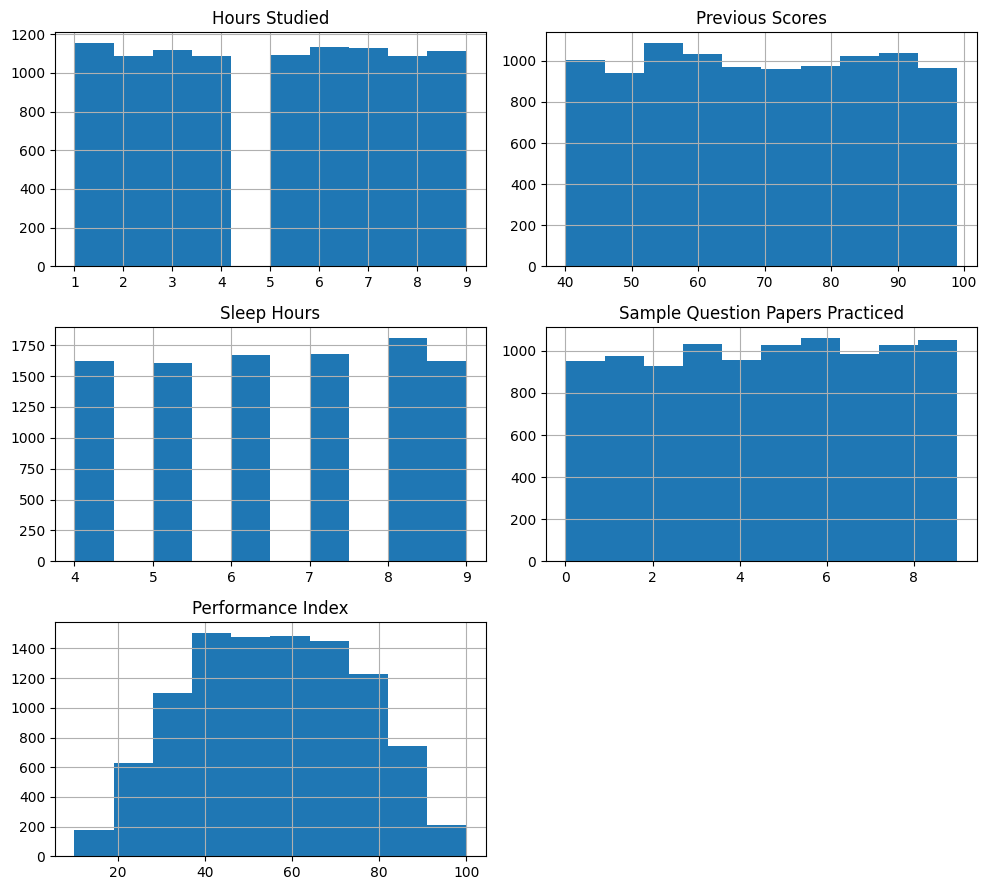

In [73]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,9))
plt.tight_layout()
plt.show()

A partir de los histogramas generados, se observa que la variable "Horas estudiadas" presenta una distribución relativamente uniforme entre 1 y 9 horas. De manera similar, la variable "Notas anteriores" presenta una distribución bastante uniforme entre 40 y 100. Por otra parte, "Horas dormidas" también presenta una distribución uniforme entre 4 y 9 horas, caso similar con "Número de exámenes practicados" que son entre 0 y 8. Por último, el "Índice de rendimiento" presenta una distribución más cercana de forma normal.

**NOTA:** Se puede observar la presencia de "huecos" entre las barras del histograma; esto es debido a que, como las variables son discretas, puede generar algunos intervalos sin datos.

##### **Boxplots**

Es una herramienta estadística gráfica que resume elementos importantes para el análisis como la distribución, variabilidad y simetría de los datos. Este incluye el mínimo, primer cuartil (Q1), mediana (Q2), tercer cuartil (Q3) y el máximo.

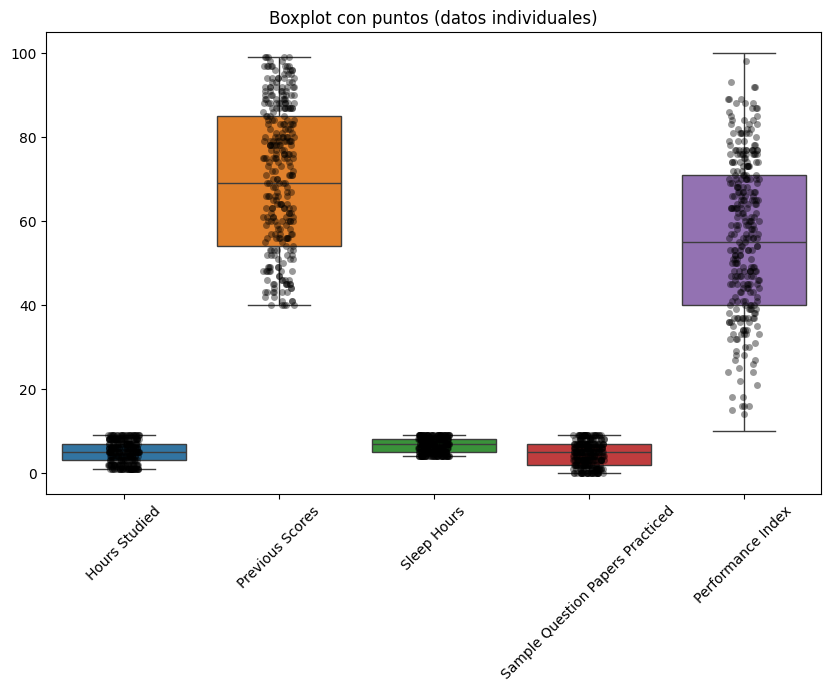

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(data=df)
sns.stripplot(data=df.sample(300), color='black', alpha=0.4)

plt.xticks(rotation=45)
plt.title("Boxplot con puntos (datos individuales)")
plt.show()

Como se puede observar en el diagrama boxplot, las variables con poca variabilidad como "Horas estudiadas", "Horas dormidas" y "Cantidad de exámenes de práctica realizados" se ven las cajas más pequeñas y los valores están muy cercanos entre sí. Por otra parte, las variables "Índice de rendimiento" y "Notas anteriores" tienen valores más dispersos, debido a su naturaleza. No obstante, ninguna de las variables tiene "outliers", dando la idea de que este es un data-set limpio.

##### **Diagramas de Dispersión**

Los diagramas de dispersión son una forma más de representación gráfica que permite visualizar y analizar la relación entre dos variables. Cada punto representa una observación del data-set. En este caso el eje X horizontal corresponde a una variable predictora, mientras que el eje vertical Y representa la variable objetivo, que en este caso es "Índice de rendimiento". Gracias a estos diagramas, se pueden identificar patrones.

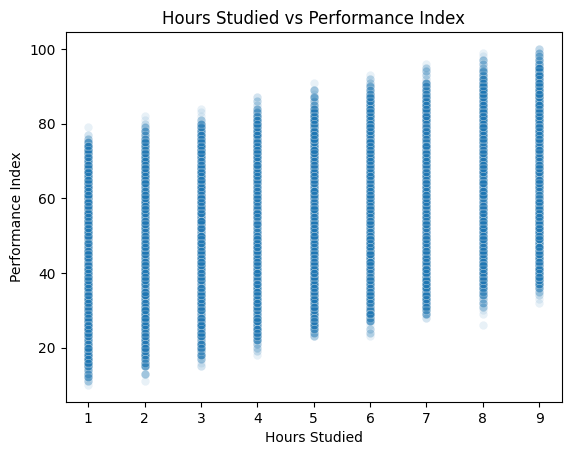

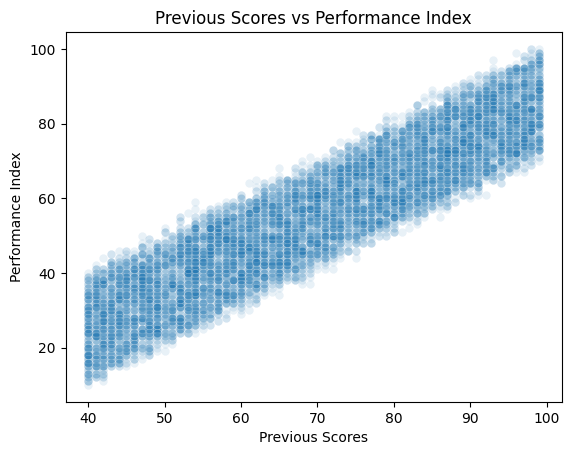

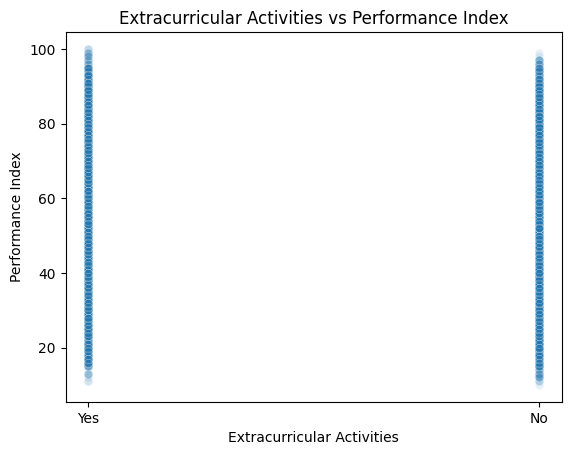

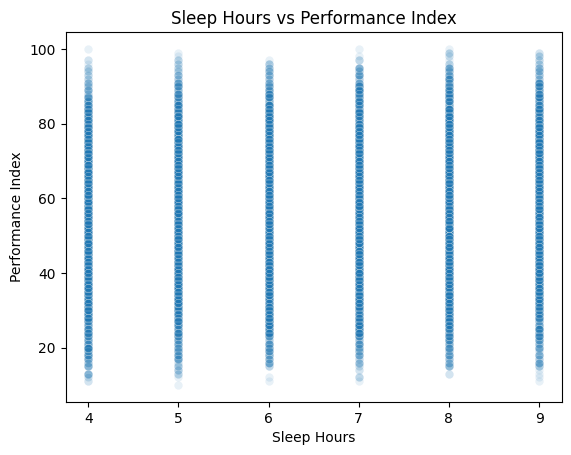

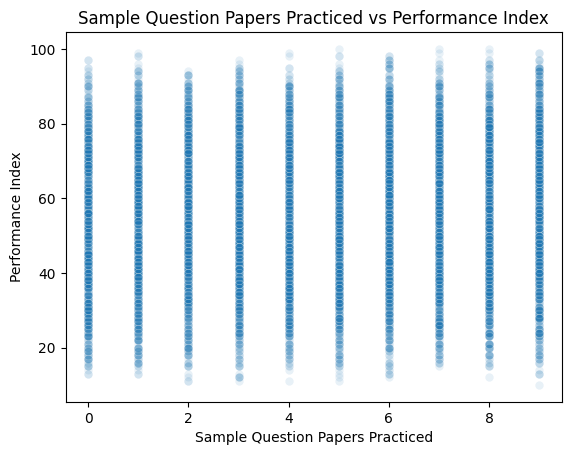

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

target = "Performance Index"


for col in df.columns:
    if col != target:
        sns.scatterplot(x=df[col], y=df[target], alpha=0.1)
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()

Realizándose un análisis breve, se puede observar como el primer diagrama "Hours studied vs Performance Index" existe, lo que se puede ver una relación positiva moderada con patrón ascendente. El segundo diagrama "Previous Scores vs Performance Index" se observa como una línea diagonal, mostrando una relación positiva muy fuerte, prácticamente lineal. El tercer diagrama de "Extracurricular Activities vs Performance Index" se observa una relación débil. El cuarto diagrama de "Sleep Hours vs Performance Index" es una relación débil al igual que la última de "Sample Question Papers vs Performance Index".

##### **Matriz de Correlación**

La matriz de correlación es una tabla que resume los coeficientes de correlación (entre -1 a +1) entre múltiples variables numéricas, midiendo la fuerza y dirección de sus relaciones lineales. Entre más se acerque a +1 es porque la relación es fuerte y -1 si es débil. Adicionalmente, con un mapa de colores se permite visualizar más fácilmente e intuitivamente las relaciones.

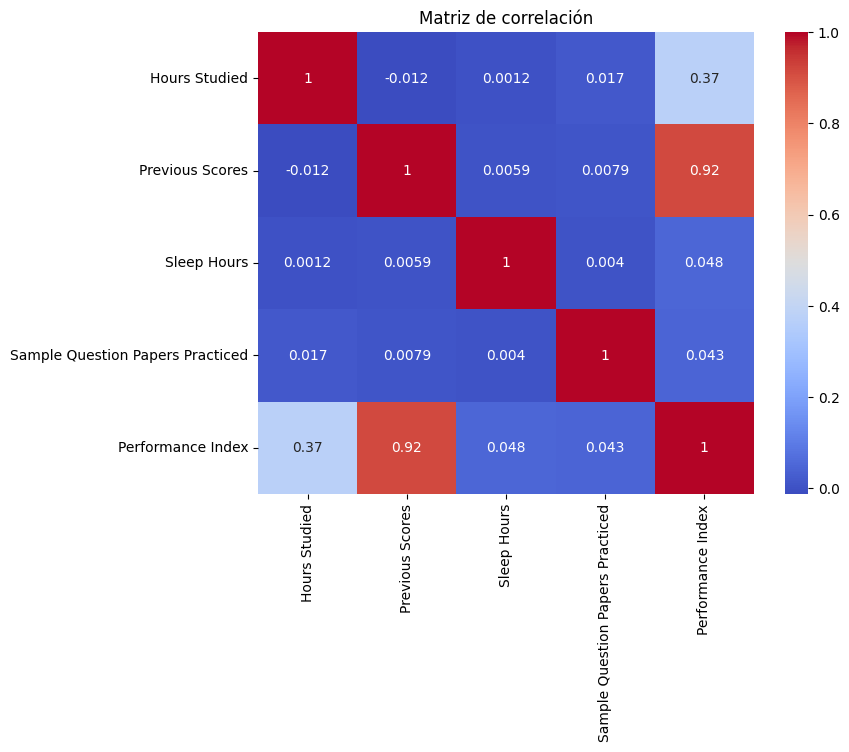

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# matriz de correlación
corr = df.corr(numeric_only=True)

# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Como se puede ver en la matriz de correlación resultante, se puede rescatar 3 datos interesantes: la relación entre "Performance Index" y "Hours studied" es de un 0.37 por lo que se considera moderada positiva. Mientras que la relación de "Performance Index" y "Previous Scores" es considerada como muy fuerte positiva. No obstante, las demás correlaciones son muy bajas o inclusive negativas.

#### **Análisis de la visualización**

En general, los resultados obtenidos a partir de los distintos tipos de diagramas presentan una alta concordancia entre sí. Los histogramas y boxplots muestran que los datos están bien distribuidos y sin valores atípicos significativos, mientras que los diagramas de dispersión permiten identificar visualmente las relaciones entre las variables y el "Performance Index". Estas relaciones se ven confirmadas en la matriz de correlación, donde se observa que variables como "Previous Scores" y "Hours Studied" presentan correlaciones positivas con el rendimiento. Por lo tanto, existe coherencia entre los distintos análisis realizados, lo que valida la consistencia del dataset y respalda la idea de aplicar modelos de regresión lineal.

Adicionalmente, se realizó la identificación de posibles valores atípicos mediante el análisis de diagramas de caja (boxplots) y visualizaciones complementarias.

A partir de los resultados, no se evidencian datos sobresalientes significativos en el dataset, ya que no se observan valores fuera de los rangos establecidos en los boxplots ni comportamientos anómalos en los histogramas o diagramas de dispersión.

Esto indica que los datos se encuentran dentro de rangos esperados y presentan una distribución consistente.

Por lo tanto, no fue necesario aplicar ningún tratamiento para la eliminación o corrección de valores atípicos.
    

#### **D) División del Data-Set**

---

En este caso se solicita dividir el data-set en 3 principales partes: Un 70% de entrenamiento, 15% en validación y 15% en pruebas. Posteriormente hacerlo con random sampling manual, sin el uso de sklearn.

In [18]:
import numpy as np

# mezclar datos aleatoriamente
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# tamaño total
n = len(df_shuffled)

# índices de corte
train_end = int(0.7 * n)
val_end = int(0.85 * n)

# dividir dataset
train_df = df_shuffled[:train_end]
val_df = df_shuffled[train_end:val_end]
test_df = df_shuffled[val_end:]

# verificar tamaños
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7000
Validation: 1500
Test: 1500


En este código, primero se realiza un paso fundamental: mezclar los datos aleatoriamente con sample(). Después reorganizamos y reseteamos los índices. Para finalmente dividir manualmente el data-set en 70%/15%/15% como fue solicitado en el trabajo. Es importante recalcar que la aleatorización de los datos ayuda a evitar sesgos en la distribución de los datos y a mejorar la generalización del modelo.

##### **Separación de variables (X & y)**

En esta sección se separan las variables predictoras (X) de la variable objetivo (y). La variable objetivo corresponde a "Performance Index", mientras que el resto de variables se utilizan como entradas del modelo. Esta separación se realiza para los conjuntos de entrenamiento, validación y prueba.

In [19]:
# convertir variable categórica
train_df['Extracurricular Activities'] = train_df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
val_df['Extracurricular Activities'] = val_df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
test_df['Extracurricular Activities'] = test_df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

target = "Performance Index"

# entrenamiento
X_train = train_df.drop(target, axis=1).values
y_train = train_df[target].values

# validación
X_val = val_df.drop(target, axis=1).values
y_val = val_df[target].values

# test
X_test = test_df.drop(target, axis=1).values
y_test = test_df[target].values


#### **E) Implementación de la Regresión Lineal**
---

En esta sección se implementa un modelo de regresión lineal desde cero utilizando la librería NumPy. Para ello, se utiliza el algoritmo de descenso de gradiente (θ:= θ−α·∇L(β)) visto en clase, el cual permite ajustar iterativamente los parámetros del modelo, con el fin de minimizar el error. Esta implementación se realiza de forma manual, sin el uso de librerías de machine learning, con el propósito de comprender el funcionamiento interno del modelo.

Se llevarán a cabo dos experimentos: uno utilizando Batch Gradient Descent (FORMA A) y otro utilizando Mini-Batch Gradient Descent (FORMA B), con el fin de comparar uno con el otro.

#### **Experimento A: Batch Gradient Descent**

Este consiste en un algoritmo de optimización que tiene como idea principal que si escogemos una pareja aleatoria de valores a y b, es posible calcular el error que estamos cometiendo. Utilizado para entrenar modelos de machine learning y redes neuronales.

##### **Normalización de los datos**

Como se ha visto en clases anteriores, es fundamental que los datos estén limpios, adecuados y normalizados, si no, nuestros resultados serán inútiles. Es por eso que después de varios intentos se llegó a la idea de que como existen variables con distintas escalas (Previous Hours 40-99, Hours Studied 1-9, etc) se ocupa que todas queden con una escala parecida para así poder compararlas. En este caso a cada variable se le resta la media y se le divide por la desviación estándar.

**Nota:** Esto solo se calcula con el training.


In [20]:
#Se calcula la media y la desviación estándar de los valores training
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

#Después se utilizan para la validación y el test
X_train = (X_train - mean_train) / std_train
X_val = (X_val - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

##### **Agregar el sesgo (bias)**

El sesgo, también conocido como bias, es un parámetro en el modelo de regresión lineal que permite ajustar la predicción. Su función es darle mayor flexibilidad al modelo, evitando que la recta de regresión quede obligada a pasar por el origen.

In [28]:
# Agregar el sesgo (bias)

# Se crea un vector de unos con la misma cantidad de filas que X_train
# Pega la columna en el inicio de la matriz
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val] 
X_test = np.c_[np.ones(X_test.shape[0]), X_test]


##### **Definición de funciones de utilidad**

La función "predict" es la encargada de calcular las predicciones a partir de los datos resultantes de la matriz de entrada y los parámetros del modelo. La función "mse" calcula qué tan cerca están las predicciones de los valores reales. Estas serán reutilizadas para la parte de "Evaluación del Modelo".

In [29]:
def predict(X, theta):
    return X @ theta

#Siendo y_true el valor y "real" o "calculado", y y_pred el valor y "de hipótesis".
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

##### **Algoritmo del experimento de Batch (A)**

Repasando y retomando lo que se vio en clase, la idea central del algoritmo es encontrar los valores de theta (los pesos) que hagan que la regresión lineal cometa el menor error posible. La meta es minimizar el MSE.

In [30]:
# X_train (variables de entrada de entrenamiento), Y_train (valores reales de entrenamiento)
# X_val (variables de validación), Y_val (valores reales de validación)
# Alpha (taza de aprendizaje), Rep (Cantidad de repeticiones)
def batch_gradient_descent(X_train, y_train, X_val, y_val, alpha=0.01, rep=1000):
    #Matriz en 0
    m, n = X_train.shape
    theta = np.zeros(n)

    #Lista para guardar el MSE
    train_losses = []
    val_losses = []

    for epoch in range(rep):
        #Calcular prediciones
        y_pred = predict(X_train, theta)
        #Calcular error
        error = y_pred - y_train

        #Formula planteada (con la derivada de MSE)
        gradient = (2 / m) * (X_train.T @ error)
        theta = theta - alpha * gradient

        train_losses.append(mse(y_train, predict(X_train, theta)))
        val_losses.append(mse(y_val, predict(X_val, theta)))

    return theta, train_losses, val_losses

Como se puede observar, primero se empieza con los pesos iniciales, se le hacen predicciones con esos pesos, después se comparan las predicciones con los valores reales, se calcula que tan grande o pequeño es el error. Por último, se calcula en que dirección se tienen que mover los pesos para reducir el error, se actualizan los pesos. Este proceso se repite varias veces.

##### **Ejecución (Entrenarlo)**

In [31]:
theta_batch, train_loss_batch, val_loss_batch = batch_gradient_descent(
    X_train, y_train, X_val, y_val,
    alpha=0.01,
    rep=1000
)

##### **Gráfica / Training VS Validation**

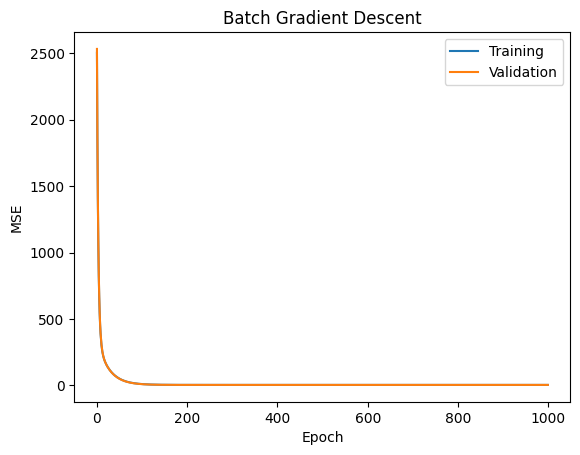

In [35]:
import matplotlib.pyplot as plt

plt.plot(train_loss_batch, label='Training')
plt.plot(val_loss_batch, label='Validation')
plt.title('Batch Gradient Descent')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

##### **F) Evaluación**
---

In [85]:
y_test_pred_batch = predict(X_test, theta_batch)
test_mse_batch = mse(y_test, y_test_pred_batch)

print("MSE en test (Batch):", test_mse_batch)

MSE en test (Batch): 4.075290567669369


#### **Experimento B: Mini Batch Gradient**

En el caso del experimento B Mini Batch Gradient, la idea general es que en este método el gradiente no se calcula con todo el conjunto de entrenamiento de una sola vez, sino con pequeños subconjuntos de datos llamados mini-batches. Esto permite realizar varias actualizaciones de los parámetros dentro de una misma época.

¡Como principales beneficios se tiene que es más rápido y mucho más flexible!

**Nota:** Debido a que los datos ya pasaron la etapa de normalización y estandarización de los datos, podemos pasar directamente a la implementación del algoritmo en si.

##### **Algoritmo del experimento de Mini Batch (B)**

In [86]:
# X_train (variables de entrada de entrenamiento), Y_train (valores reales de entrenamiento)
# X_val (variables de validación), Y_val (valores reales de validación)
# Alpha (tasa de aprendizaje), Rep (Cantidad de repeticiones), Batch_size (tamaño de cada mini-batch)
def mini_batch_gradient_descent(X_train, y_train, X_val, y_val, alpha=0.01, rep=1000, batch_size=32):
    # Matriz en 0
    m, n = X_train.shape
    theta = np.zeros(n)

    # Lista para guardar el MSE
    train_losses = []
    val_losses = []

    for epoch in range(rep):
        # Mezclar datos aleatoriamente en cada repetición
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        # Recorrer pequeños grupos de datos
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Calcular prediciones del mini-batch
            y_pred_batch = predict(X_batch, theta)
            # Calcular error del mini-batch
            error_batch = y_pred_batch - y_batch

            # Formula planteada (con la derivada de MSE)
            gradient = (2 / len(y_batch)) * (X_batch.T @ error_batch)
            theta = theta - alpha * gradient

        train_losses.append(mse(y_train, predict(X_train, theta)))
        val_losses.append(mse(y_val, predict(X_val, theta)))

    return theta, train_losses, val_losses

##### **Ejecución (Entrenarlo)**

In [87]:
theta_mini, train_loss_mini, val_loss_mini = mini_batch_gradient_descent(
    X_train, y_train, X_val, y_val,
    alpha=0.01,
    rep=1000,
    batch_size=32
)

##### **Gráfica / Training VS Validation**

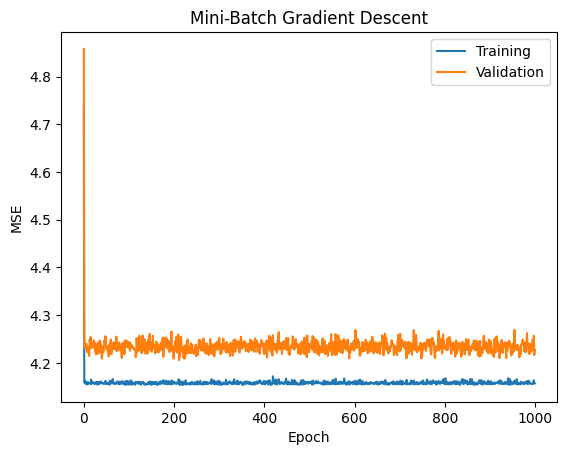

In [91]:
import matplotlib.pyplot as plt

plt.plot(train_loss_mini, label='Training')
plt.plot(val_loss_mini, label='Validation')
plt.title('Mini-Batch Gradient Descent')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

##### **F) Evaluación**
---

In [92]:
y_test_pred_mini = predict(X_test, theta_mini)
test_mse_mini = mse(y_test, y_test_pred_mini)

print("MSE en test (Mini-Batch):", test_mse_mini)

MSE en test (Mini-Batch): 4.091310300257087


#### **G) Análisis de Resultados**
---